In [1]:
# Importing packages
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.optimize import curve_fit
import mc_simulation as mc


In [2]:
# Basic parameters

sigma_0 = 1.0     # Hard-core diameter
sigma_1 = 2.5     # Soft-shoulder diameter
epsilon = 1.0     # Energy unit
T_target = 0.1    # Target temperature for task 1

### Optimal $\delta $ parameters

In [3]:
# The proposed function for the model
def exp_decay(delta, A0, k):
    return A0 * np.exp(-k * delta)

# The analytical function to get optimal step size for target acceptance
def calculate_optimal_delta(A0_fit, k_fit, target_acceptance=0.30):
    return -np.log(target_acceptance / A0_fit) / k_fit

# Input parameter grid matching the simulation values 
step_sizes = np.linspace(0.05, 0.65, 5)

# Load the parameters from the simulation
loaded_data = np.load("recalibrated_deltas_N36.npz")
results = {float(k): loaded_data[k] for k in loaded_data.files}

# 3. Fit curves and derive optimal delta for each density
optimal_deltas = {}
fit_params = {}

print("Density (rho) | Fitted A0 | Fitted k | Optimal Delta (Target 30%)")
print("-" * 65)

for rho, acc_rates in sorted(results.items()):
    # Initial guesses - to make the fit easier A0 ~ 1.0 (100% acceptance at delta=0), k ~ 1.5 decay rate
    p0 = [1.0, 1.5]
    
    # Fitting the curves
    popt, pcov = curve_fit(exp_decay, step_sizes, acc_rates, p0=p0)
    A0_fit, k_fit = popt
    
    # Compute the optimal delta that yields target acceptance (30% was suggested in the task papaer)
    delta_opt = calculate_optimal_delta(A0_fit, k_fit, target_acceptance=0.30)
    
    # Store the resutls
    fit_params[rho] = (A0_fit, k_fit)
    optimal_deltas[rho] = delta_opt
    
    print(f"   {rho:.3f}      |  {A0_fit:.4f}  |  {k_fit:.4f}  |      {delta_opt:.4f}")

Density (rho) | Fitted A0 | Fitted k | Optimal Delta (Target 30%)
-----------------------------------------------------------------
   0.100      |  0.9963  |  1.0844  |      1.1068
   0.150      |  0.9842  |  3.5156  |      0.3379
   0.227      |  0.9661  |  5.8390  |      0.2003
   0.291      |  0.8546  |  7.1585  |      0.1462
   0.380      |  0.8127  |  9.2892  |      0.1073


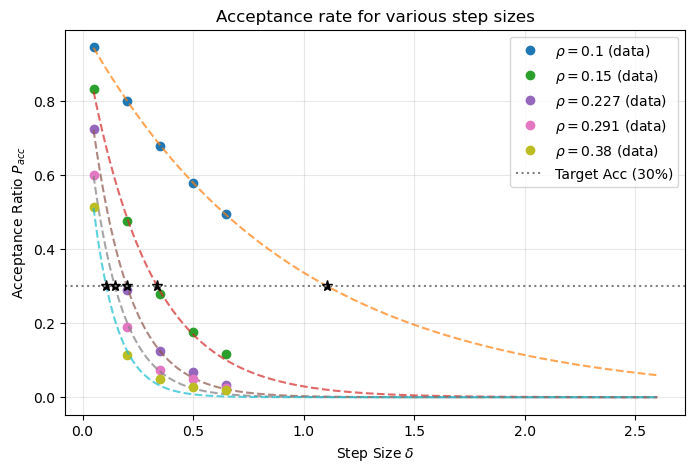

In [6]:
# Visualize the results
plt.figure(figsize=(8, 5))
delta_dense = np.linspace(0.05, 2.6, 200)

for rho, acc_rates in sorted(results.items()):
    A0_fit, k_fit = fit_params[rho]
    delta_opt = optimal_deltas[rho]
    
    # Scatter plot of simulation sweeps
    plt.plot(step_sizes, acc_rates, 'o', label=f"$\\rho = {rho}$ (data)")
    
    # Plot the analytical fitted solution
    fit_curve = exp_decay(delta_dense, A0_fit, k_fit)
    plt.plot(delta_dense, fit_curve, '--', alpha=0.7)
    
    # Mark the targeted value of 0.3
    plt.plot(delta_opt, 0.30, 'k*', markersize=8)

plt.axhline(0.30, color='gray', linestyle=':', label='Target Acc (30%)')
plt.xlabel("Step Size $\\delta$")
plt.ylabel("Acceptance Ratio $P_{acc}$")
plt.title("Acceptance rate for various step sizes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Test simulation: N = 100 , eq_moves = $10^6$, prod moves = $10^7$, $\rho = 0.1$

=== Starting Phase A Sweep: N=100, T*=0.1 ===

 Running Density rho* = 0.1


Equilibrating (rho*=0.1):   0%|          | 0/1000000 [00:00<?, ?move/s]

Equilibration Finished (rho*=0.1) | Acceptance: 31.46%


Production   (rho*=0.1):   0%|          | 0/10000000 [00:00<?, ?move/s]

Production Finished   (rho*=0.1) | Acceptance: 31.38%



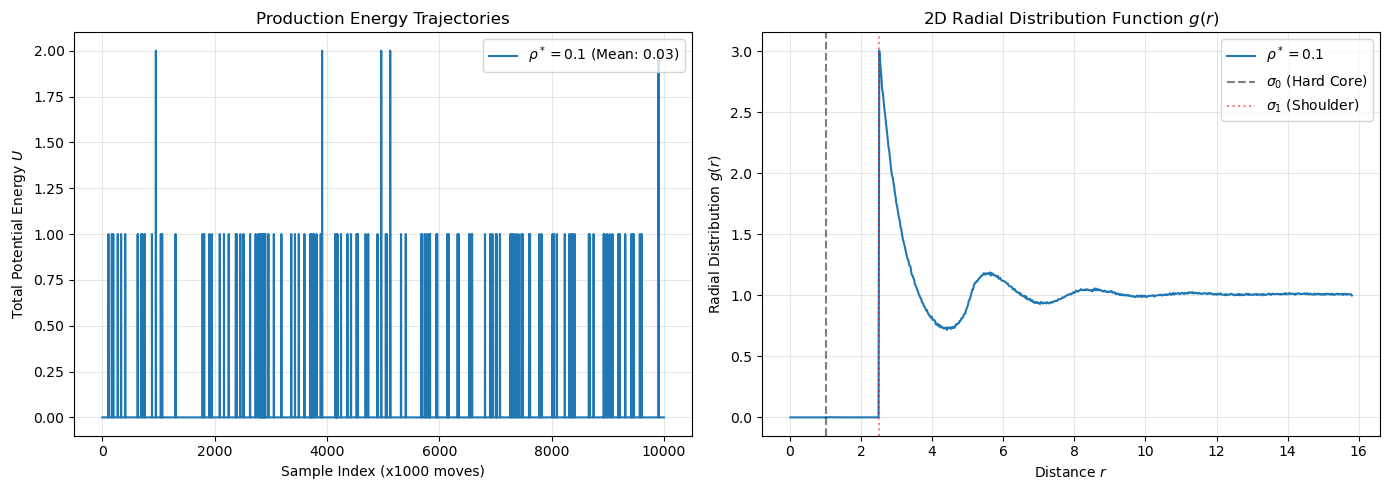

In [ ]:
"""

#-------------------------------------------------------------------------------------------------------
# Remove " symbols to run!
#-------------------------------------------------------------------------------------------------------

# Simulation Parameters 
N = 100
T_star = 0.1
densities = [0.10]

delta = optimal_deltas[0.1]
eq_moves = 1_000_000        # 1M moves for equilibration
prod_moves = 10_000_000      # 10M moves for production sampling
sample_interval = 1_000     # Sample trajectory every 1,000 steps

results = {}

print(f"=== Starting Phase A Sweep: N={N}, T*={T_star} ===")

for rho in densities:
    print(f"\n" + "="*50)
    print(f" Running Density rho* = {rho}")
    print("="*50)

    # Create a random layout
    x, y = mc.hot_start(N=N, rho=rho)

    # Pre-equilibration to remove hard-core overlaps
    x, y, success, sweeps = mc.pre_equilibrate(
        x, y, T_high=100, U_cap=800, delta_pre_eq=0.50, rho=rho, N=N
    )
    if not success:
        print(f"Warning: Pre-equilibration failed for rho*={rho}")
        continue

    # Equilibration - 10^6 Steps
    x, y, eq_moves_hist, eq_e_hist, eq_acc = mc.equilibrate_continuous(
        x, y, target_T=T_star, total_moves=eq_moves, delta=delta,
        sample_interval=sample_interval, rho=rho, N=N
    )

    # Production
    x, y, prod_moves_hist, prod_e_hist, trajectory, prod_acc = mc.run_production_sampling(
        x, y, target_T=T_star, total_moves=prod_moves, delta=delta,
        sample_interval=sample_interval, rho=rho, N=N
    )

    # Radial Distribution Function g(r)
    Length = np.sqrt(N / rho)
    r_centers, g_r = mc.compute_gr_2d(trajectory, Length, dr=0.02)

    # Save results dictionary
    results[rho] = {
        "energy_history": prod_e_hist,
        "mean_U": np.mean(prod_e_hist),
        "std_U": np.std(prod_e_hist),
        "r": r_centers,
        "g_r": g_r,
        "trajectory": trajectory,
        "Length": Length
    }

# Plotting Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Potential Energy Trajectories
for rho, data in results.items():
    ax1.plot(data["energy_history"], label=f"$\\rho^*={rho}$ (Mean: {data['mean_U']:.2f})")
ax1.set_xlabel("Sample Index (x1000 moves)")
ax1.set_ylabel("Total Potential Energy $U$")
ax1.set_title("Production Energy Trajectories")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: 2D Radial Distribution Function g(r)
for rho, data in results.items():
    ax2.plot(data["r"], data["g_r"], label=f"$\\rho^*={rho}$")
ax2.axvline(x=1.0, color="k", linestyle="--", alpha=0.5, label="$\\sigma_0$ (Hard Core)")
ax2.axvline(x=2.5, color="r", linestyle=":", alpha=0.5, label="$\\sigma_1$ (Shoulder)")
ax2.set_xlabel("Distance $r$")
ax2.set_ylabel("Radial Distribution $g(r)$")
ax2.set_title("2D Radial Distribution Function $g(r)$")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
"""

In [ ]:
"""
# Save the results dictionary to a file
with open("mc_simulation_0.1.pkl", "wb") as f:
    pickle.dump(results, f)

print("Results successfully saved to 'mc_simulation_results.pkl'!")
"""

Results successfully saved to 'mc_simulation_results.pkl'!


#### Test 2 - optimized deltas, eq_moves = $2 \cdot 10^6$, prod_moves = $2\cdot 10^7$, all densities

In [ ]:

import pickle
import numpy as np
import mc_simulation as mc

# Parameters
N = 100
T_star = 0.1
densities = [0.10, 0.15, 0.227, 0.291, 0.38]  # All 5 Phase A target densities



eq_moves = 2_000_000  # 2M moves for equilibration 
prod_moves = 20_000_000  # 20M moves for production sampling
sample_interval = 1_000  # Sample trajectory and energy every 1,000 steps

print(f"=== Starting Phase A Data Collection: N={N}, T*={T_star} ===")

for rho in densities:
    delta = optimal_deltas[rho]

    print("\n" + "=" * 55)
    print(
        f" Running Density rho* = {rho} | delta = {delta:.4f} | Prod Moves = {prod_moves:,}"
    )
    print("=" * 55)

    # Creating a hot start configuration
    x, y = mc.hot_start(N=N, rho=rho)

    # Running pre equilibrium to remove hard-core overlaps
    x, y, success, sweeps = mc.pre_equilibrate(
        x, y, T_high=100, U_cap=800, delta_pre_eq=0.50, rho=rho, N=N
    )
    if not success: 
        print(f"ERROR: Pre-equilibration failed for rho*={rho}. Skipping...")
        continue

    # Running equilibration (2 x 10^6 steps)
    x, y, eq_moves_hist, eq_e_hist, eq_acc = mc.equilibrate_continuous(
        x,
        y,
        target_T=T_star,
        total_moves=eq_moves,
        delta=delta,
        sample_interval=sample_interval,
        rho=rho,
        N=N,
    )

    # Running production sampling (2 x 10^7 steps)
    (
        x,
        y,
        prod_moves_hist,
        prod_e_hist,
        trajectory,
        prod_acc,
    ) = mc.run_production_sampling(
        x,
        y,
        target_T=T_star,
        total_moves=prod_moves,
        delta=delta,
        sample_interval=sample_interval,
        rho=rho,
        N=N,
    )

    # Radial distribution function g(r) Calculation
    Length = np.sqrt(N / rho)
    r_centers, g_r = mc.compute_gr_2d(trajectory, Length, dr=0.02)

    # Save results into a directory
    single_density_result = {
        "rho": rho,
        "N": N,
        "T_star": T_star,
        "delta": delta,
        "eq_energy_history": eq_e_hist,
        "prod_energy_history": prod_e_hist,
        "mean_U": np.mean(prod_e_hist),
        "std_U": np.std(prod_e_hist),
        "r": r_centers,
        "g_r": g_r,
        "trajectory": trajectory,
        "Length": Length,
        "eq_acceptance": eq_acc,
        "prod_acceptance": prod_acc,
    }

    # Save file immediately after each simulation finishes
    filename = f"mc_simulation2_{rho}.pkl"
    with open(filename, "wb") as f:
        pickle.dump(single_density_result, f)

    print(f"--> Successfully saved data for rho*={rho} to '{filename}'")

print("\n=== Phase A Data Collection Complete! All pickle files saved. ===")


=== Starting Phase A Data Collection: N=100, T*=0.1 ===

 Running Density rho* = 0.1 | delta = 1.1068 | Prod Moves = 20,000,000


Equilibrating (rho*=0.1):   0%|          | 0/2000000 [00:00<?, ?move/s]

Equilibration Finished (rho*=0.1) | Acceptance: 31.62%


Production   (rho*=0.1):   0%|          | 0/20000000 [00:00<?, ?move/s]

Production Finished   (rho*=0.1) | Acceptance: 31.65%

--> Successfully saved data for rho*=0.1 to 'mc_simulation2_0.1.pkl'

 Running Density rho* = 0.15 | delta = 0.3379 | Prod Moves = 20,000,000


...

Production Finished   (rho*=0.291) | Acceptance: 28.67%

--> Successfully saved data for rho*=0.291 to 'mc_simulation2_0.291.pkl'

 Running Density rho* = 0.38 | delta = 0.1073 | Prod Moves = 20,000,000


Equilibrating (rho*=0.38):   0%|          | 0/2000000 [00:00<?, ?move/s]

Equilibration Finished (rho*=0.38) | Acceptance: 29.22%


Production   (rho*=0.38):   0%|          | 0/20000000 [00:00<?, ?move/s]

Production Finished   (rho*=0.38) | Acceptance: 24.24%

--> Successfully saved data for rho*=0.38 to 'mc_simulation2_0.38.pkl'

=== Phase A Data Collection Complete! All pickle files saved. ===


Loaded 'run2-N100-VG\mc_simulation2_0.1.pkl' successfully.
Loaded 'run2-N100-VG\mc_simulation2_0.15.pkl' successfully.
Loaded 'run2-N100-VG\mc_simulation2_0.227.pkl' successfully.
Loaded 'run2-N100-VG\mc_simulation2_0.291.pkl' successfully.
Loaded 'run2-N100-VG\mc_simulation2_0.38.pkl' successfully.


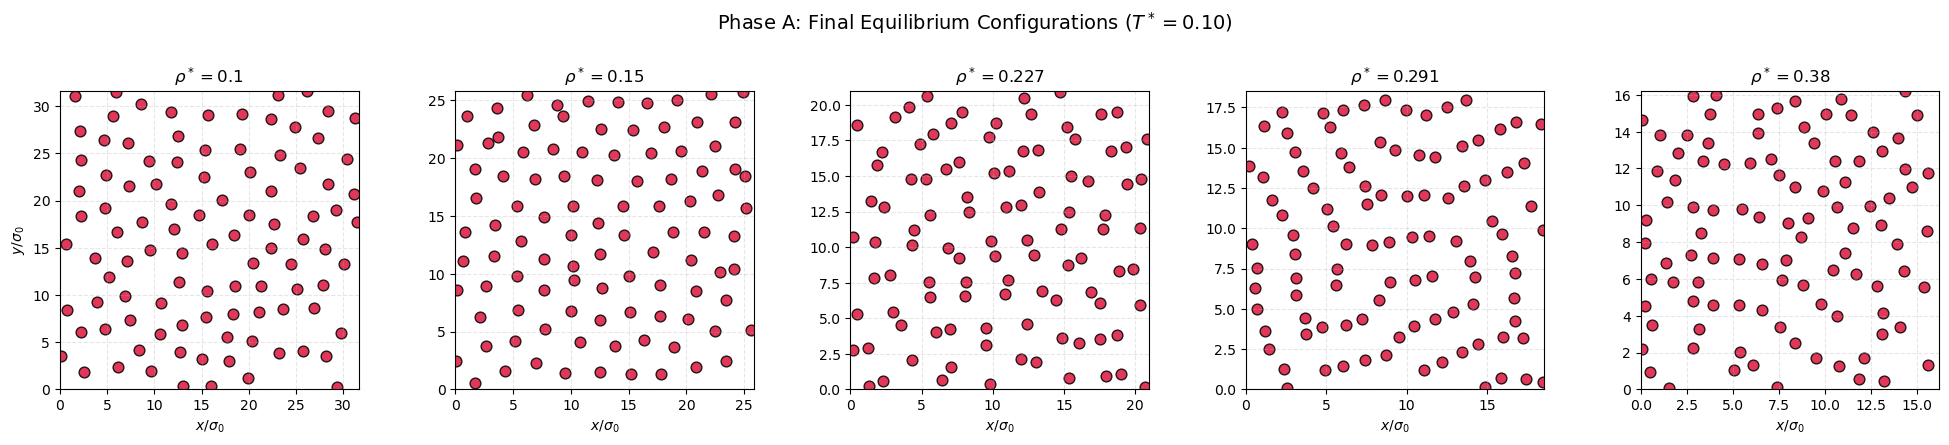

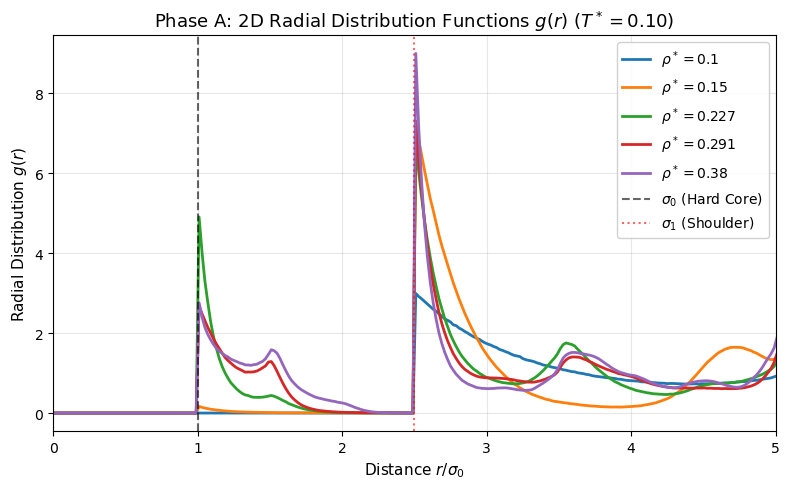

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

densities = [0.10, 0.15, 0.227, 0.291, 0.380]
results = {}

# Load saved data from individual pickle files
for rho in densities:
    filename = f"run2-N100-VG\mc_simulation2_{rho}.pkl"
    try:
        with open(filename, "rb") as f:
            results[rho] = pickle.load(f)
        print(f"Loaded '{filename}' successfully.")
    except FileNotFoundError:
        print(f"Warning: File '{filename}' not found. Skipping...")

# 2D Final configurational snapshots
fig_snapshots, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4))
if len(results) == 1:
    axes = [axes]

for ax, (rho, data) in zip(axes, results.items()):
    final_frame = data["trajectory"][-1]
    x_coords = final_frame[:, 0]
    y_coords = final_frame[:, 1]
    L = data["Length"]

    # Plot hard-core particle centers (scaled by sigma_0)
    ax.scatter(x_coords, y_coords, color="crimson", edgecolors="black", s=60, alpha=0.85, label="Particles")
    
    # Format 2D Box
    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_aspect("equal")
    ax.set_title(f"$\\rho^* = {rho}$", fontsize=12)
    ax.set_xlabel("$x / \\sigma_0$")
    if ax == axes[0]:
        ax.set_ylabel("$y / \\sigma_0$")
    ax.grid(True, linestyle="--", alpha=0.3)

plt.suptitle("Phase A: Final Equilibrium Configurations ($T^* = 0.10$)", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# Plot radial distribution functions g(r)
plt.figure(figsize=(8, 5))

for rho, data in results.items():
    plt.plot(data["r"], data["g_r"], label=f"$\\rho^* = {rho}$", linewidth=2)

# Mark key soft-shoulder radii
plt.axvline(x=1.0, color="k", linestyle="--", alpha=0.6, label="$\\sigma_0$ (Hard Core)")
plt.axvline(x=2.5, color="r", linestyle=":", alpha=0.6, label="$\\sigma_1$ (Shoulder)")

plt.xlabel("Distance $r / \\sigma_0$", fontsize=11)
plt.ylabel("Radial Distribution $g(r)$", fontsize=11)
plt.title("Phase A: 2D Radial Distribution Functions $g(r)$ ($T^* = 0.10$)", fontsize=13)
plt.xlim(0, 5.0)
plt.legend(frameon=True, facecolor="white", framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()